In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI
# Import RemoveMessage to signal the graph to delete specific messages from the state
from langchain.messages import RemoveMessage

In [2]:
load_dotenv()

True

In [3]:
model = ChatMistralAI(model="mistral-small-2506")

In [4]:
# Basic chat node
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

# Cleanup node to delete older messages and keep the state small
def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # If there are more than 10 messages in the state, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        # Returning RemoveMessage(id=m.id) tells LangGraph to delete these messages from the state
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    # If 10 or fewer messages, don't delete anything
    return {}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [6]:
builder.add_edge(START, "chat")
# Run the cleanup node after every chat response to maintain state size
builder.add_edge("chat", "cleanup")
builder.add_edge("cleanup", "__end__")

In [7]:
# Compile with memory
graph = builder.compile(checkpointer=InMemorySaver())

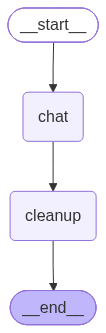

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [10]:
# Run multiple turns to build up the message history
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='c2c5edfb-d010-4b2b-85ee-704083d0a99c'),
  AIMessage(content='# **What is LangChain?**\n\n**LangChain** is an **open-source framework** designed to simplify the development of applications powered by **Large Language Models (LLMs)** like GPT-4, Llama, or Claude. It provides tools, components, and abstractions to help developers **build, deploy, and scale** AI-driven applications efficiently.\n\nLangChain is particularly useful for:\n- **Chaining LLM calls** (e.g., retrieval, reasoning, execution).\n- **Integrating external tools** (APIs, databases, search engines).\n- **Managing conversation history** (memory).\n- **Creating autonomous agents** (multi-step workflows).\n- **Deploying AI applications** (local or cloud-based).\n\n---\n\n## **🔧 Core Components of LangChain**\nLangChain is organized into **modules** that handle different aspects of AI application development:\n\n| **Compon

In [12]:
# Check how many messages are actually stored in the state
# It should be less than the total turns because the cleanup node deleted the older ones
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
